# Лабораторная работа №2 — стохастические методы

Ноутбук-исследование: запускает все эксперименты, строит таблицу сравнения и графики.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('.').resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import seed_everything
from experiments import run_all_experiments

seed_everything(42)

42

## Запуск всех экспериментов

In [2]:
outcome = run_all_experiments(seed=42)
summary = outcome['summary']
summary

,group,function,method,iterations,elapsed_time_sec,value_calls,gradient_calls,hessian_calls,memory_scalars,final_value,distance_to_optimum,final_value_eps,final_point_eps
0,smooth,Quadratic-6D-good,Gradient descent,10,0.006583,11,10,0,12,1.925927e-10,1.855126e-09,5.139363e-02,1.833828e-01
1,smooth,Quadratic-6D-good,Nelder-Mead,250,0.925717,2097,0,0,42,1.983843e+00,1.917487e+00,6.213864e-01,1.450423e-01
2,smooth,Quadratic-6D-good,Newton,1,0.000751,2,1,1,48,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-04
3,smooth,Quadratic-6D-good,Simulated Annealing,1500,0.582781,1501,0,0,12,7.842201e-02,4.068951e-01,7.366626e-05,1.000000e-04
4,smooth,Quadratic-6D-good,Particle Swarm,120,1.430360,4840,0,0,726,0.000000e+00,1.535979e-03,0.000000e+00,1.000000e-04
5,smooth,Quadratic-4D-bad,Gradient descent,300,0.131439,301,300,0,8,9.601030e-04,4.294663e-02,2.903857e+232,2.409920e+115
6,smooth,Quadratic-4D-bad,Nelder-Mead,250,0.490621,1654,0,0,20,2.698074e+01,6.241317e+00,5.936359e+01,7.862634e-01
7,smooth,Quadratic-4D-bad,Newton,1,0.000548,2,1,1,24,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-04
8,smooth,Quadratic-4D-bad,Simulated Annealing,1500,0.409340,1501,0,0,8,5.663611e-03,1.155111e-02,1.197496e-04,1.000000e-04
9,smooth,Quadratic-4D-bad,Particle Swarm,120,0.984898,4840,0,0,484,5.000000e-07,3.906893e-04,5.000000e-07,1.000000e-04


## Сводное сравнение по группам

In [3]:
agg = summary.groupby(['group', 'method']).agg(
    mean_calls=('value_calls', 'mean'),
    mean_iter=('iterations', 'mean'),
    mean_dist=('distance_to_optimum', 'mean'),
    mean_mem=('memory_scalars', 'mean'),
).round(3)
agg

mean_calls  mean_iter  mean_dist  mean_mem
group         method                                                         
discontinuous Nelder-Mead            1215.000    250.000      2.939     6.000
              Particle Swarm         2430.000     80.000      3.958   182.000
              Simulated Annealing    1501.000   1500.000      3.294     4.000
multimodal    Nelder-Mead            1213.500    250.000    159.030     6.000
              Particle Swarm         3335.000     90.000      0.000   212.000
              Simulated Annealing    1501.000   1500.000    231.171     4.000
smooth        Gradient descent        180.667    179.667   5040.686     8.667
              Nelder-Mead            1725.333    250.000      3.368    24.667
              Newton                  120.000     27.333      0.099    29.000
              Particle Swarm         4840.000    120.000      0.148   524.333
              Simulated Annealing    1501.000   1500.000      0.189     8.667

## Графики сходимости (по функциям)

### Quadratic-6D-good

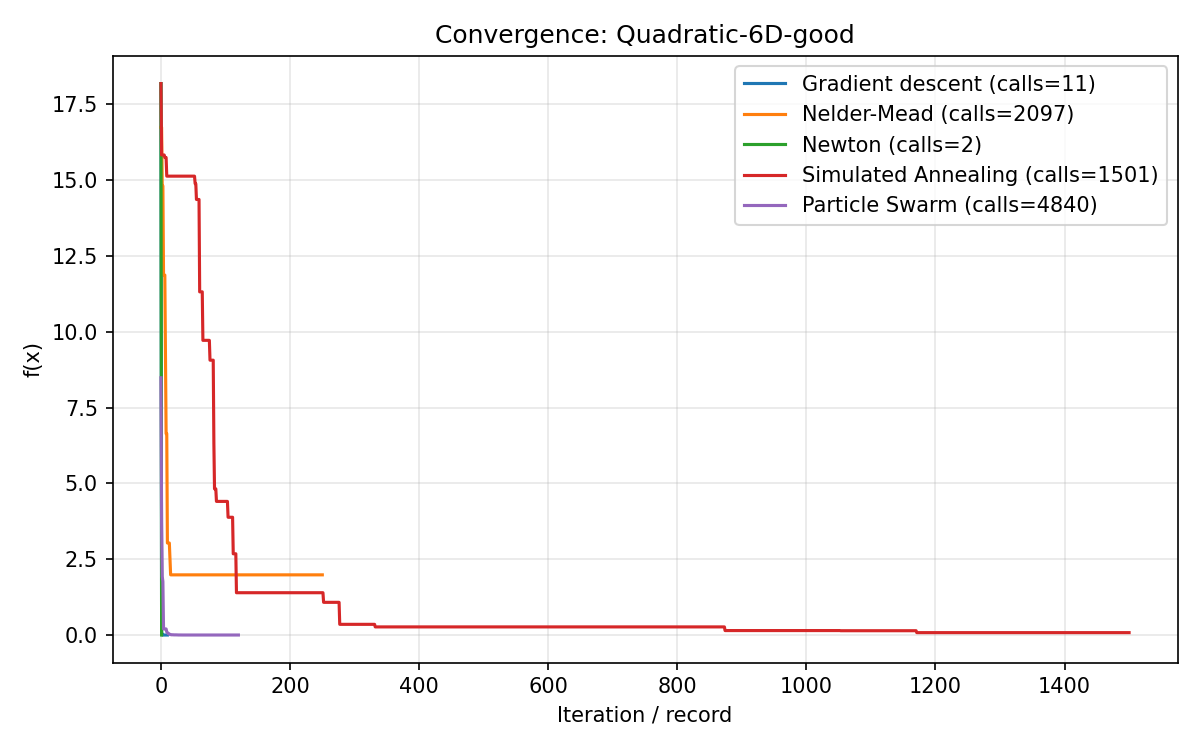

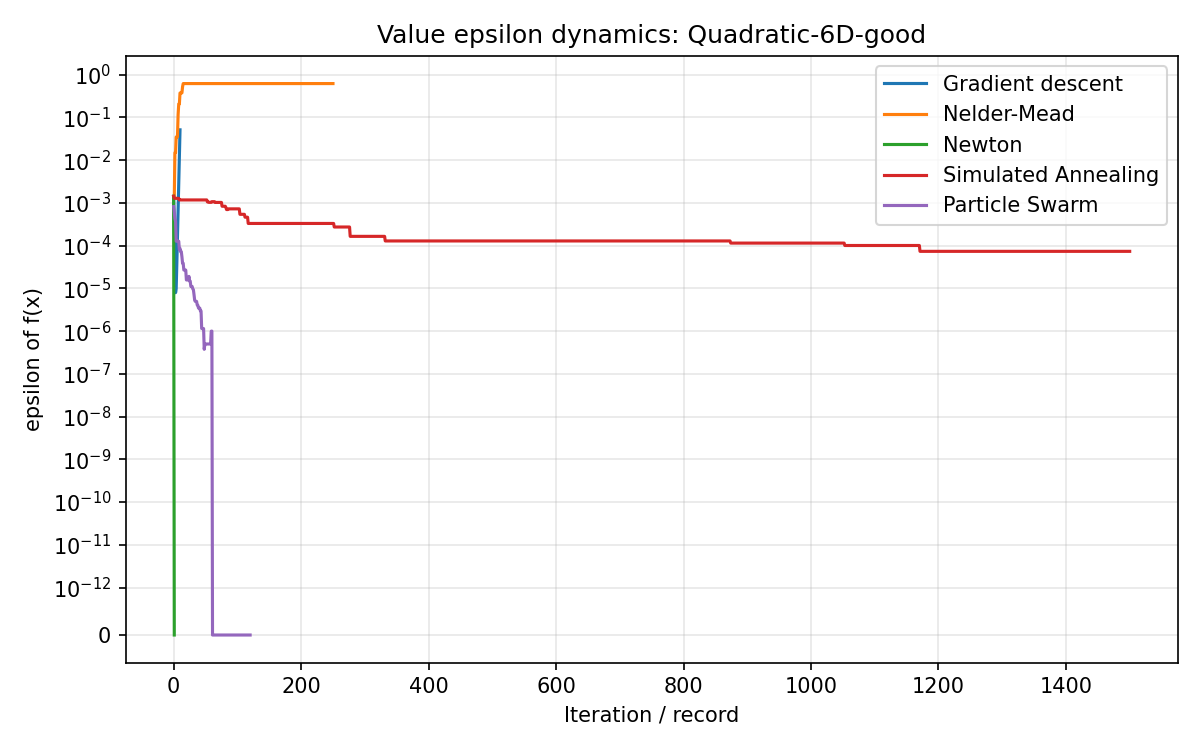

### Quadratic-4D-bad

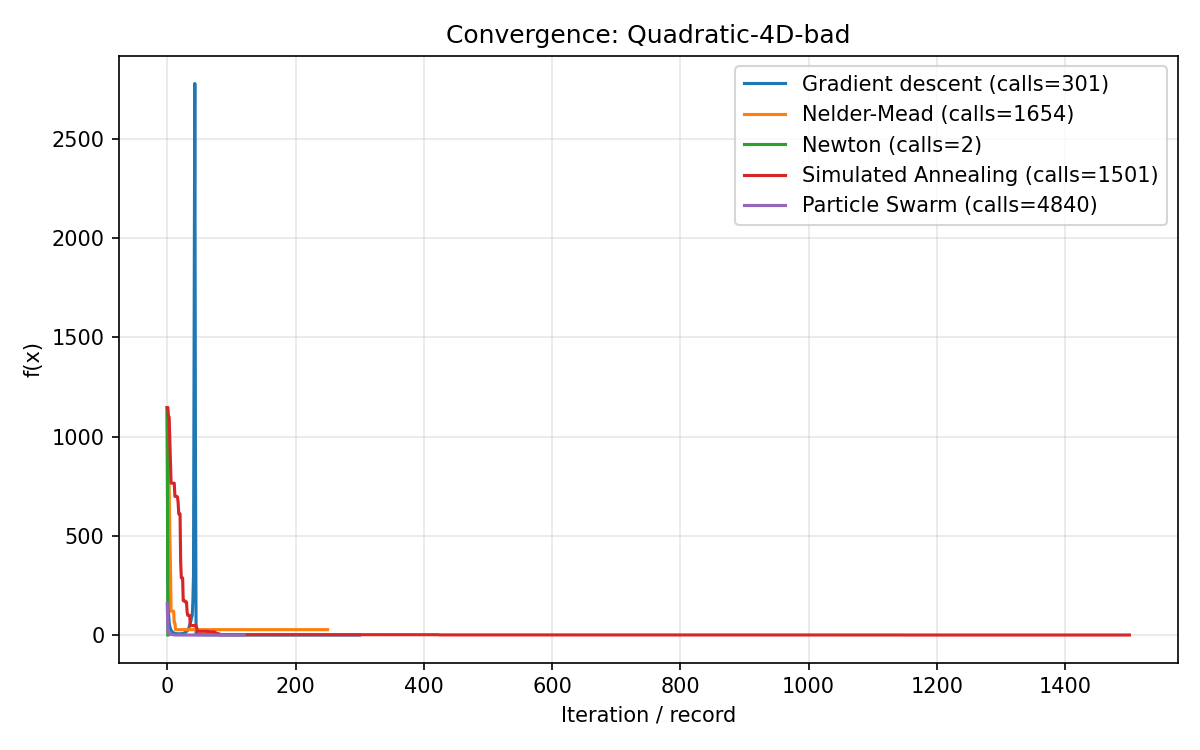

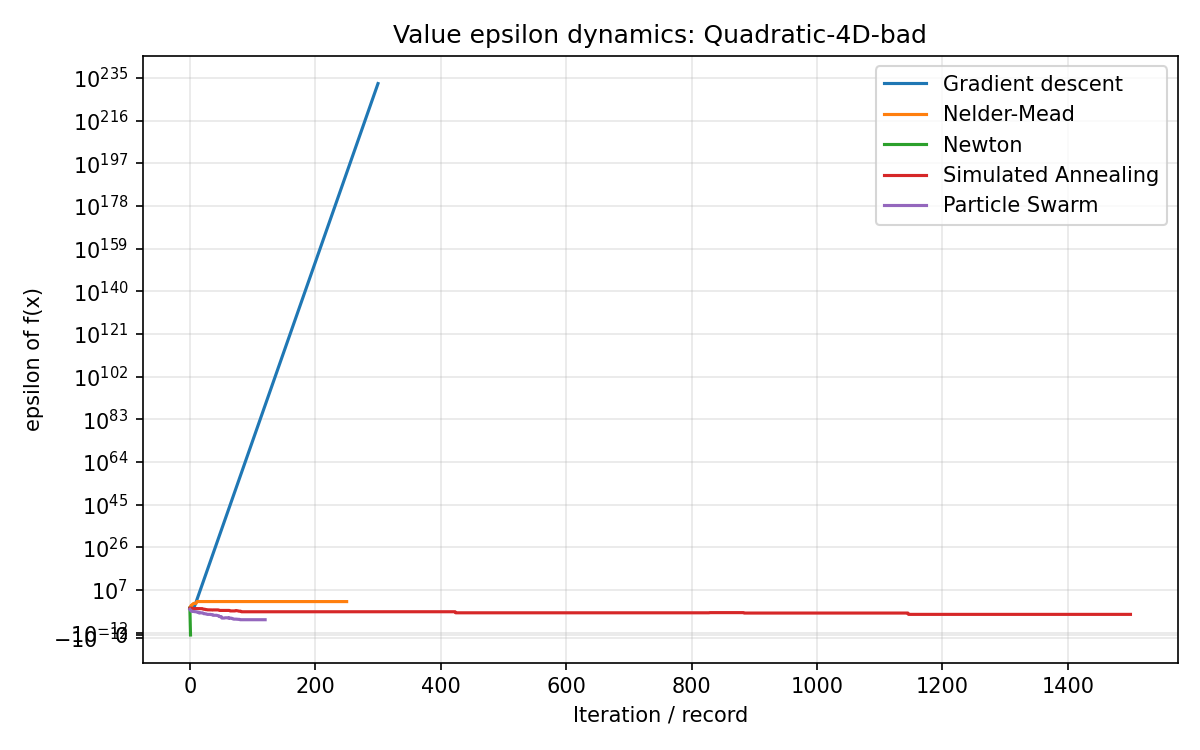

### Rosenbrock-3D

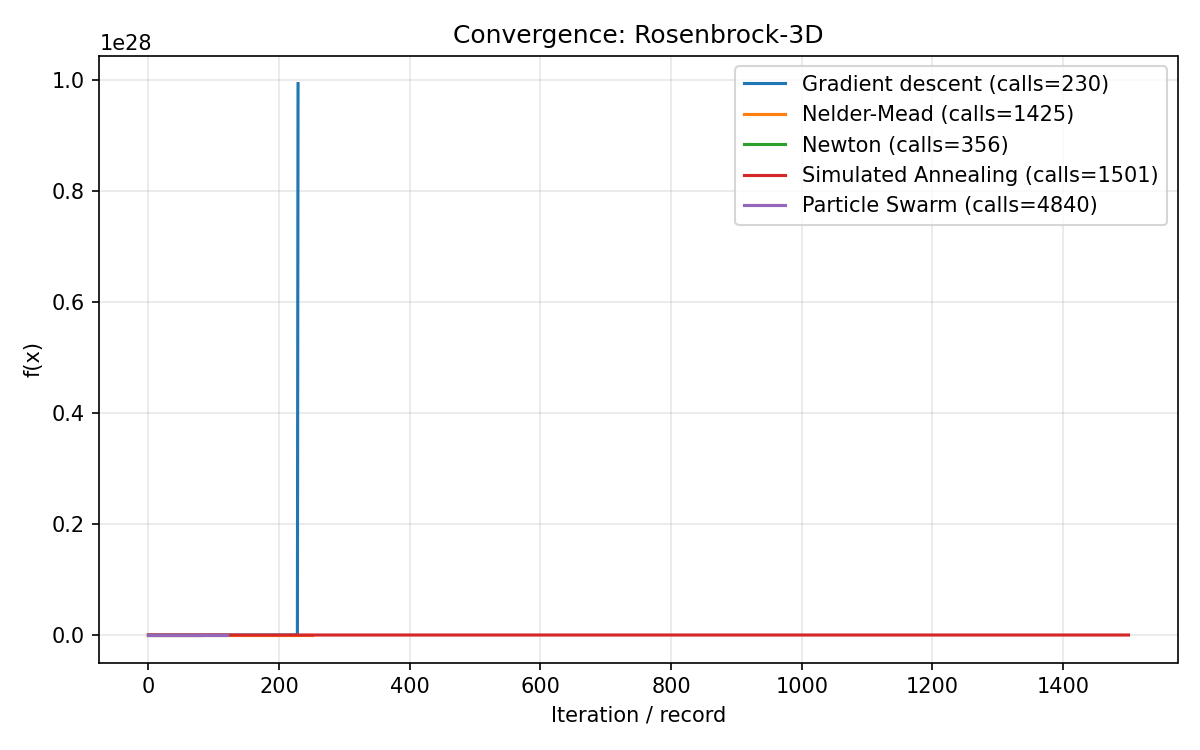

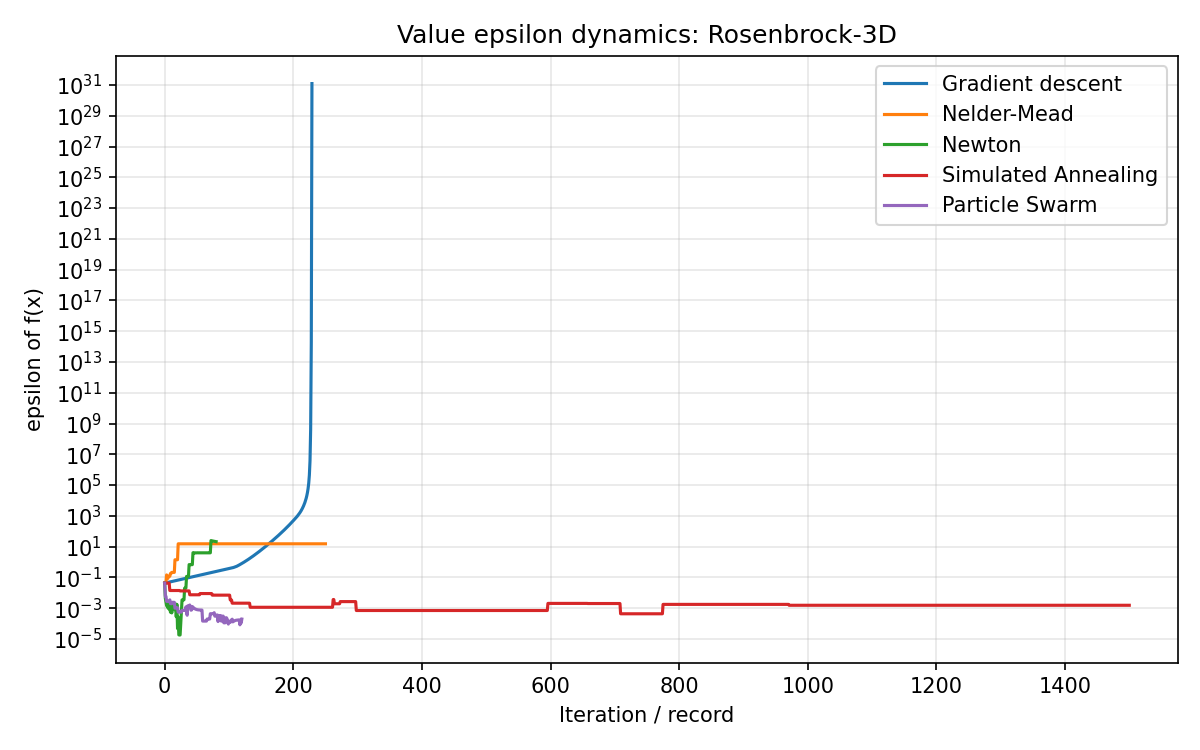

### Rastrigin-2D

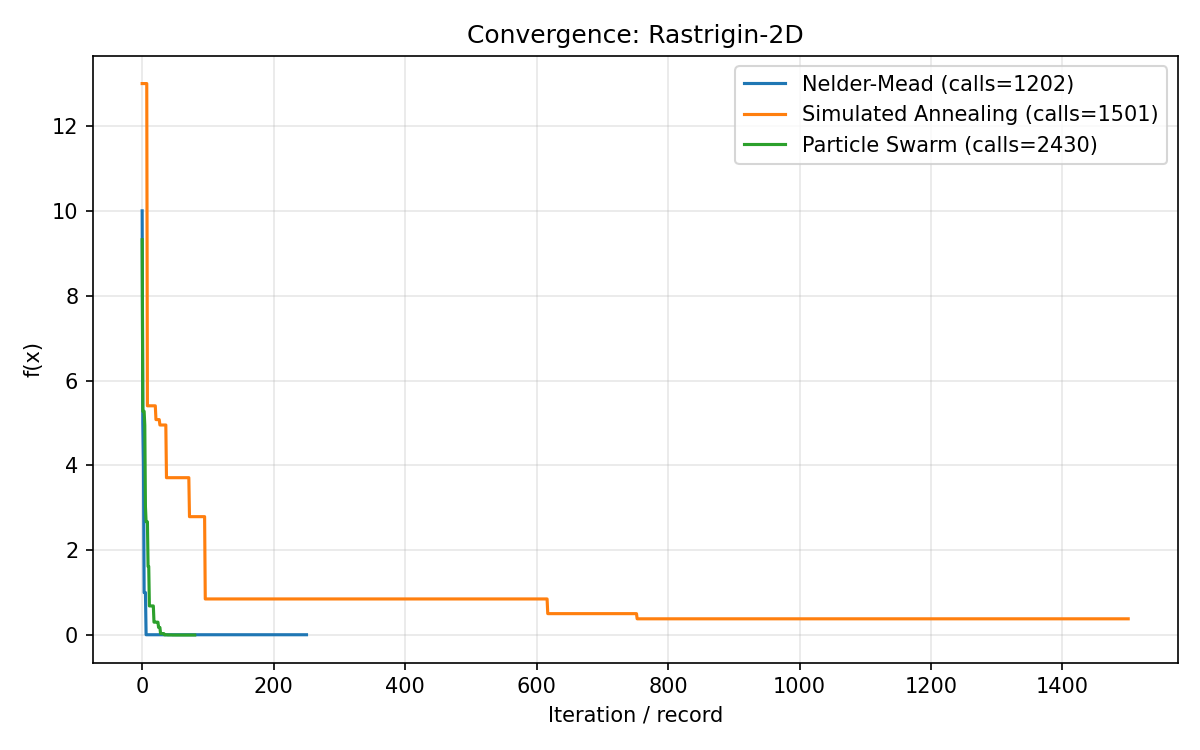

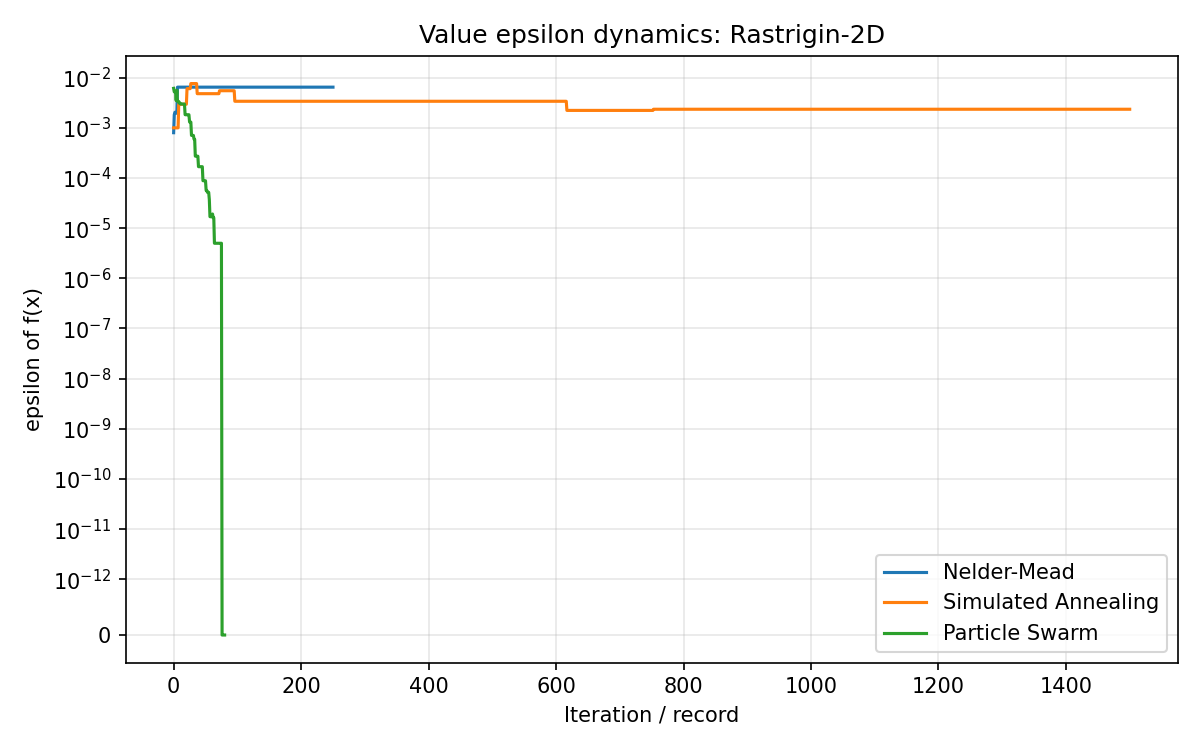

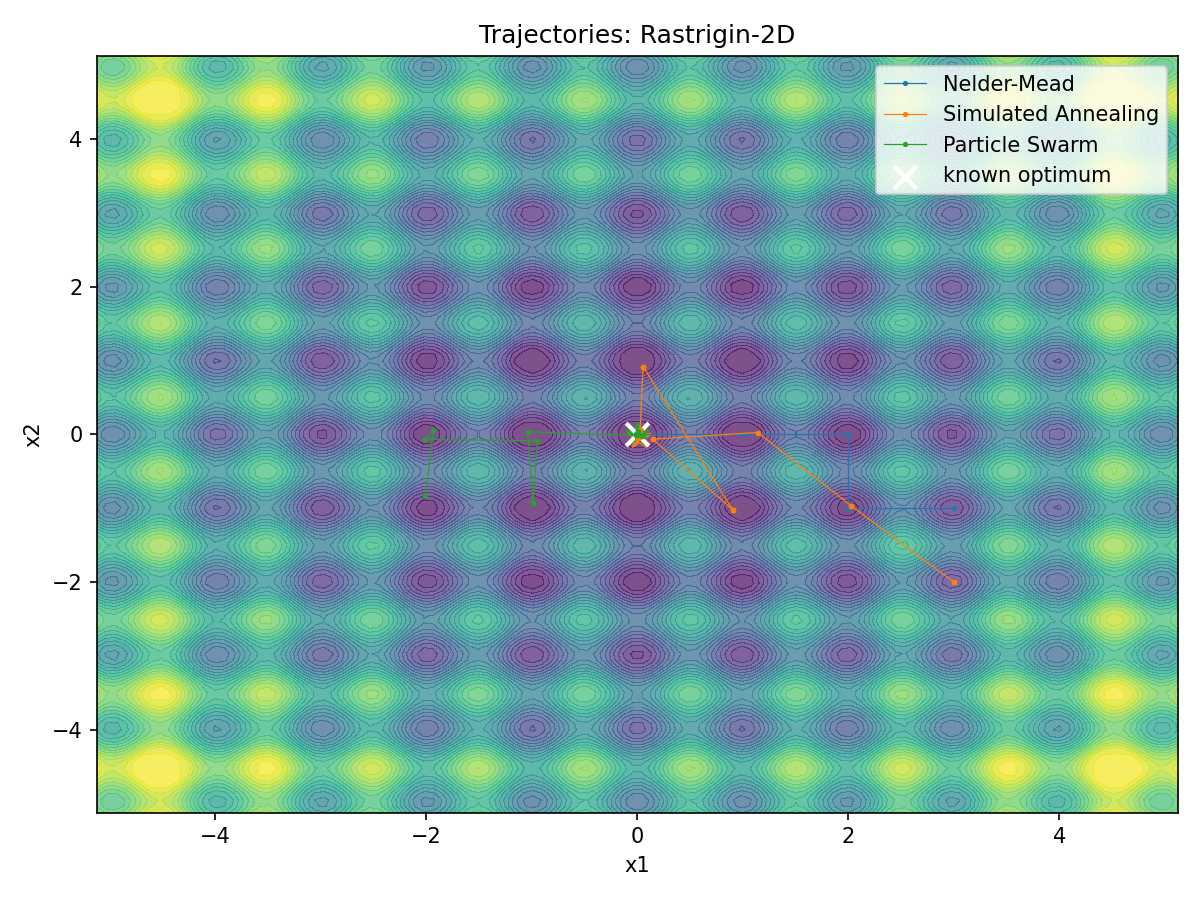

### Ackley-2D

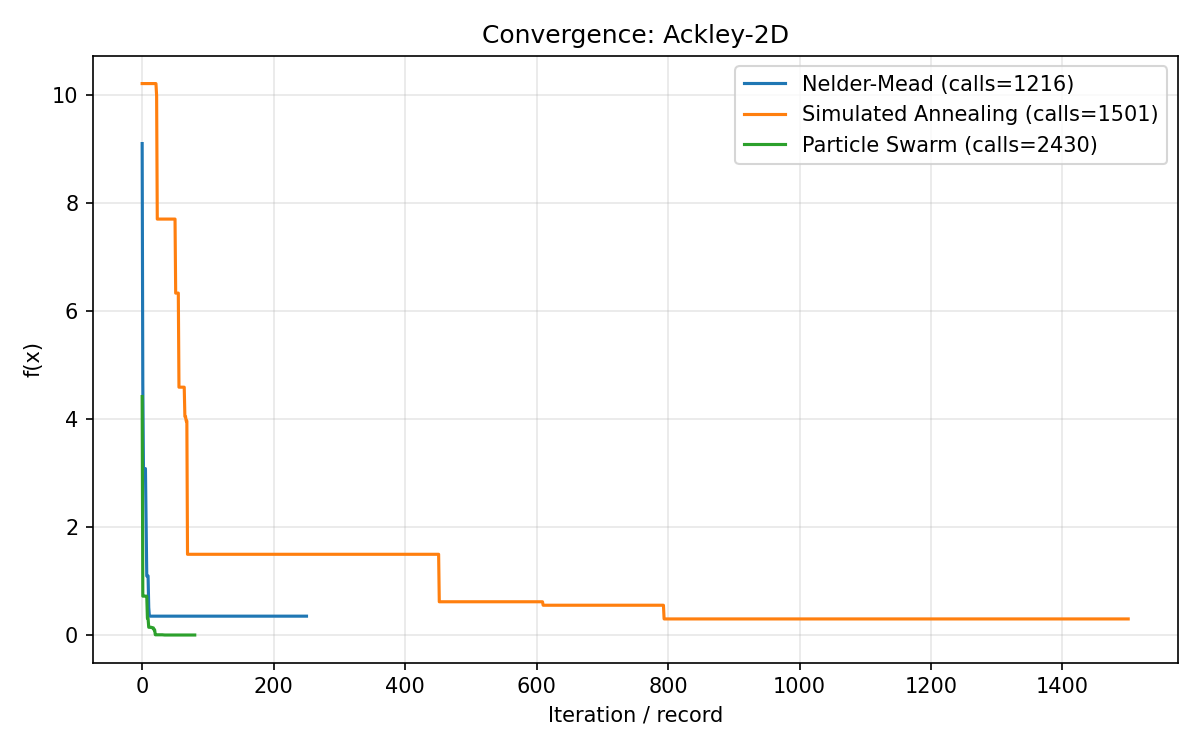

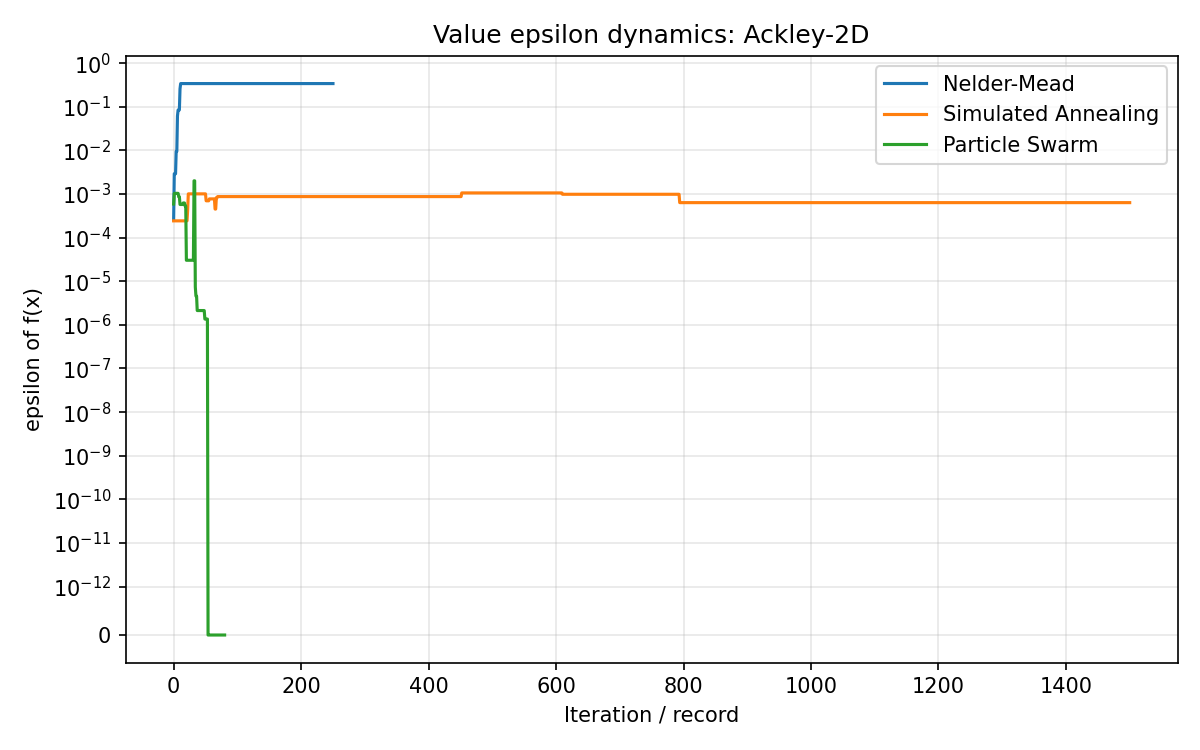

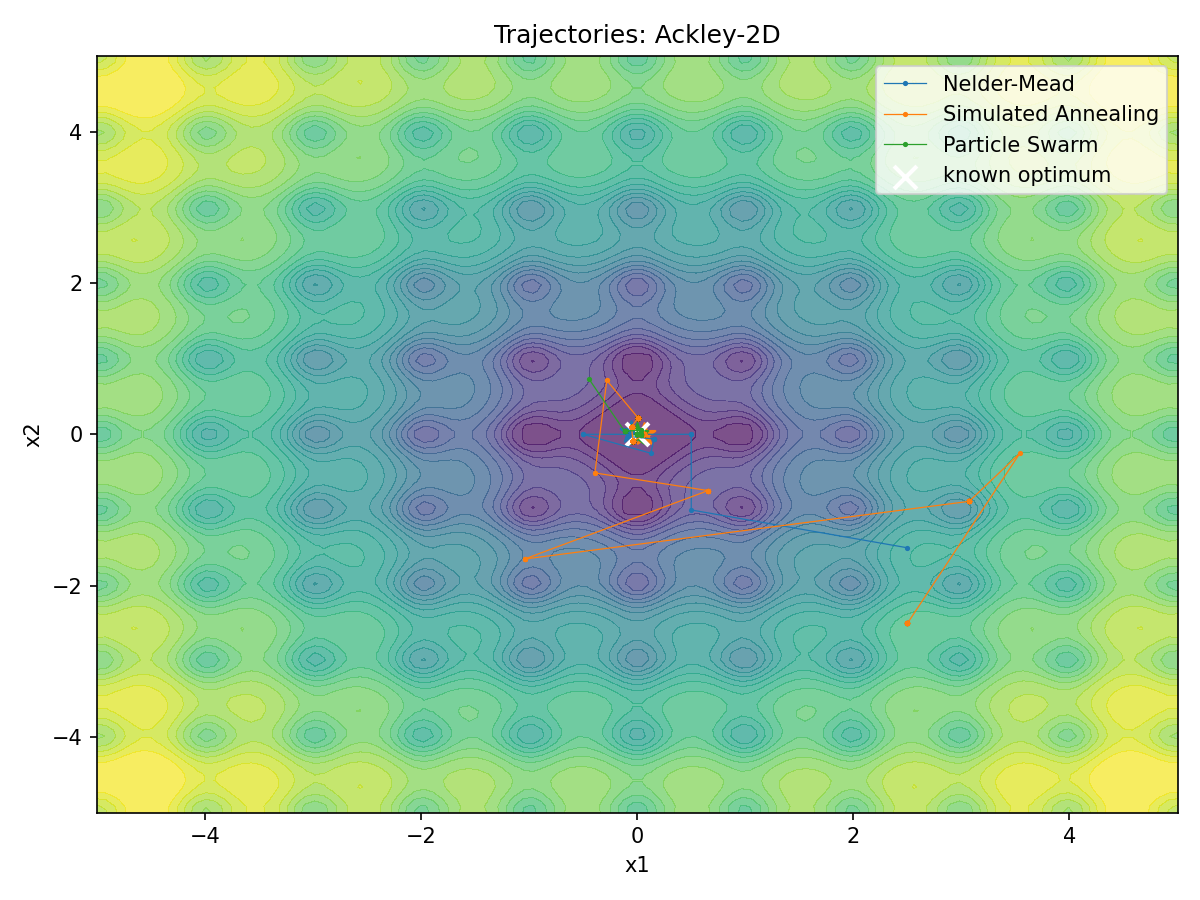

### Himmelblau-2D

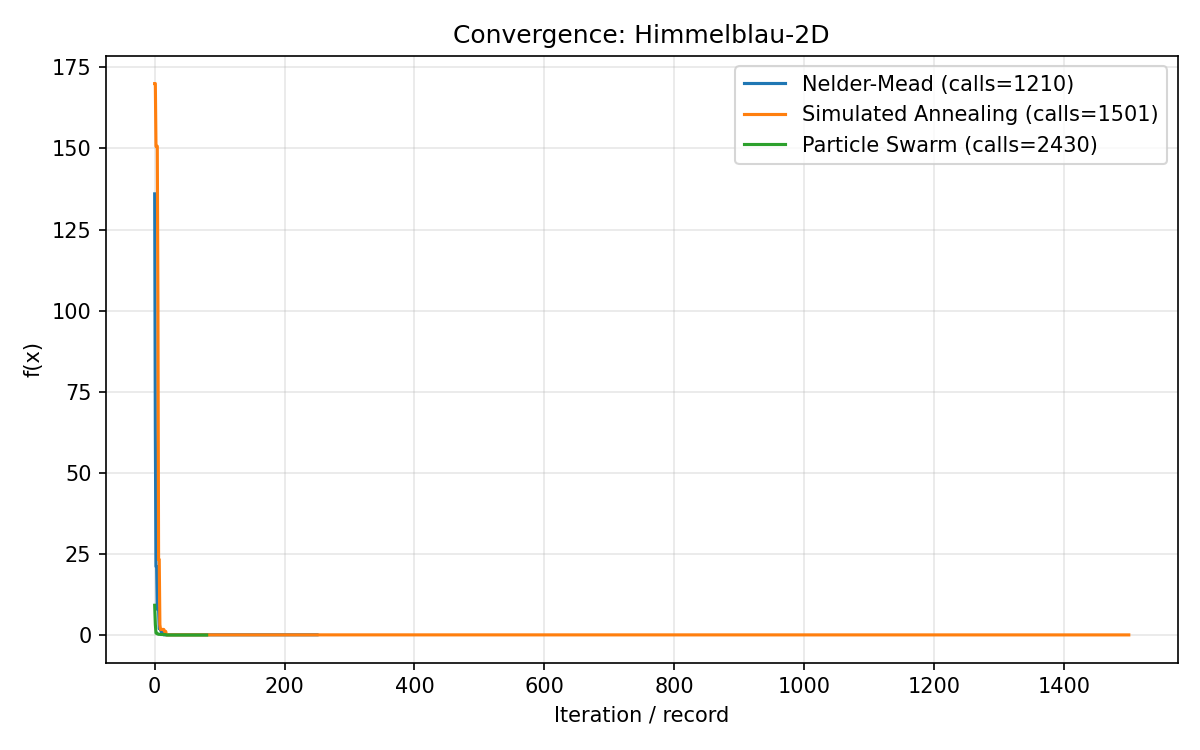

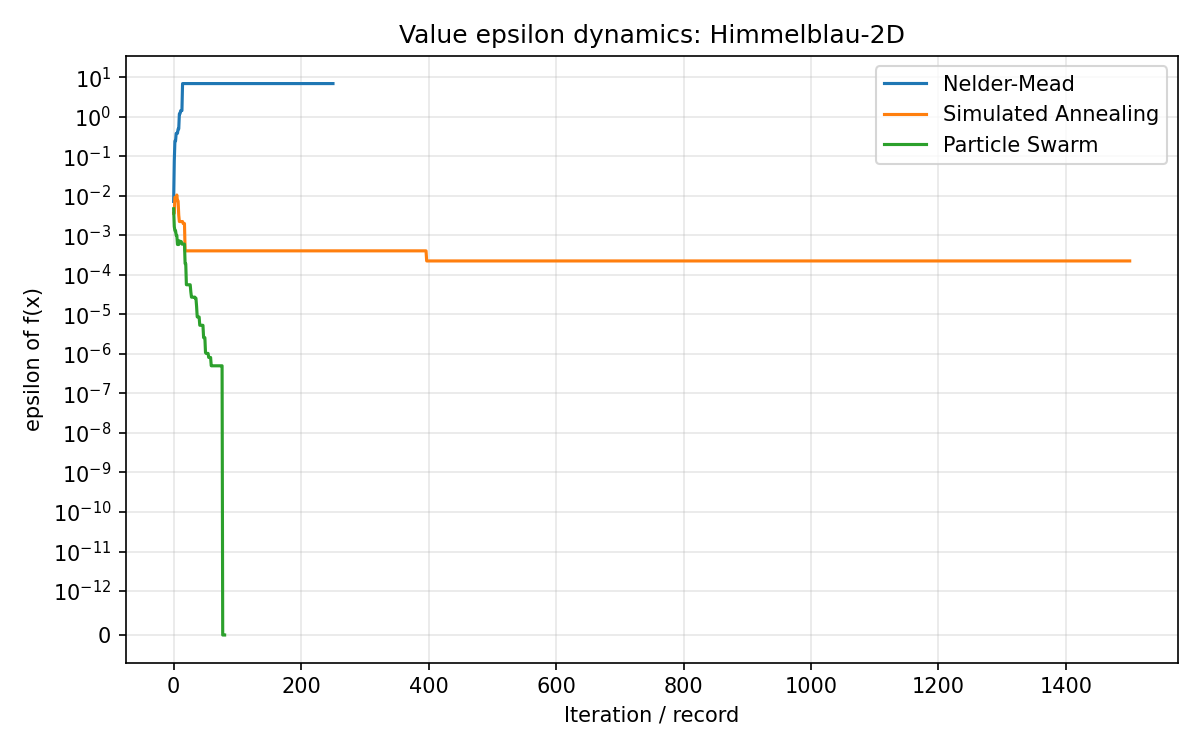

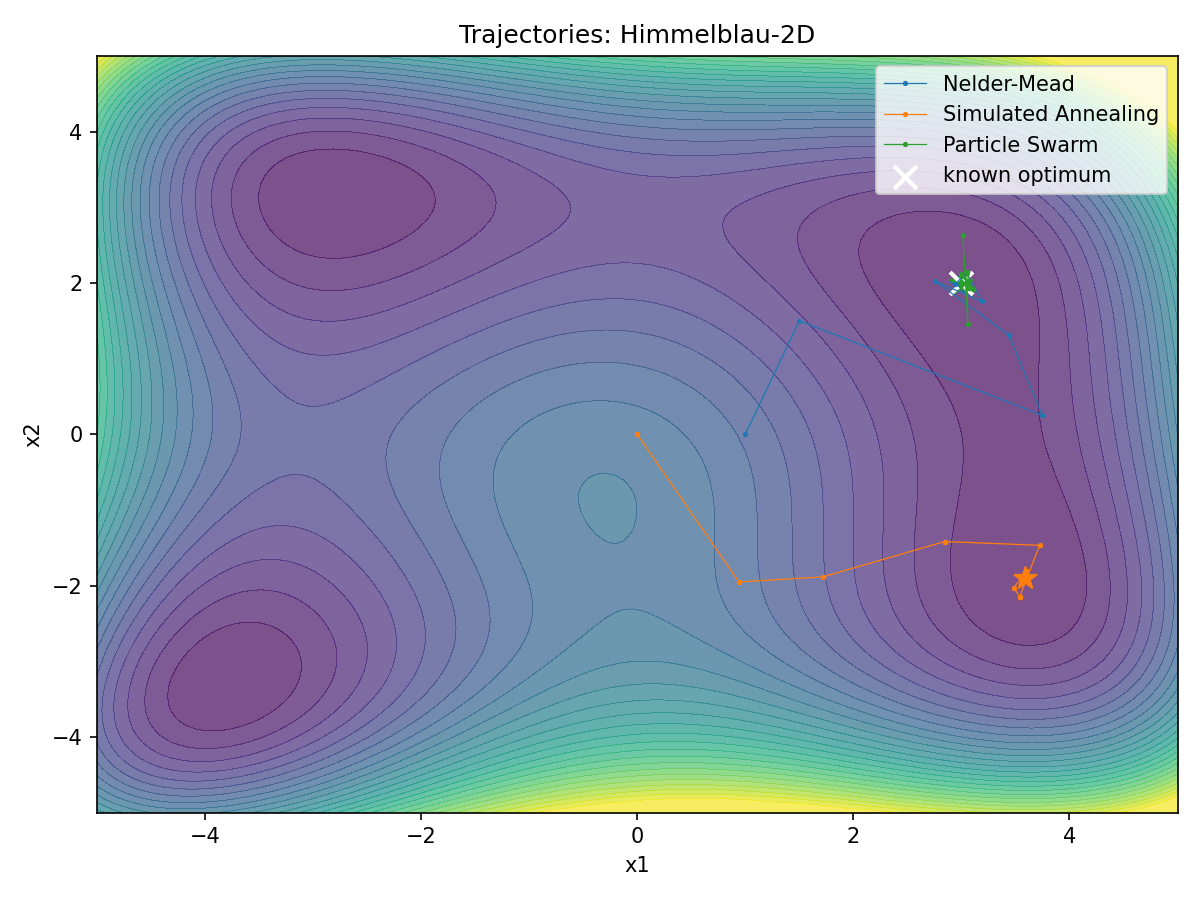

### Eggholder-2D

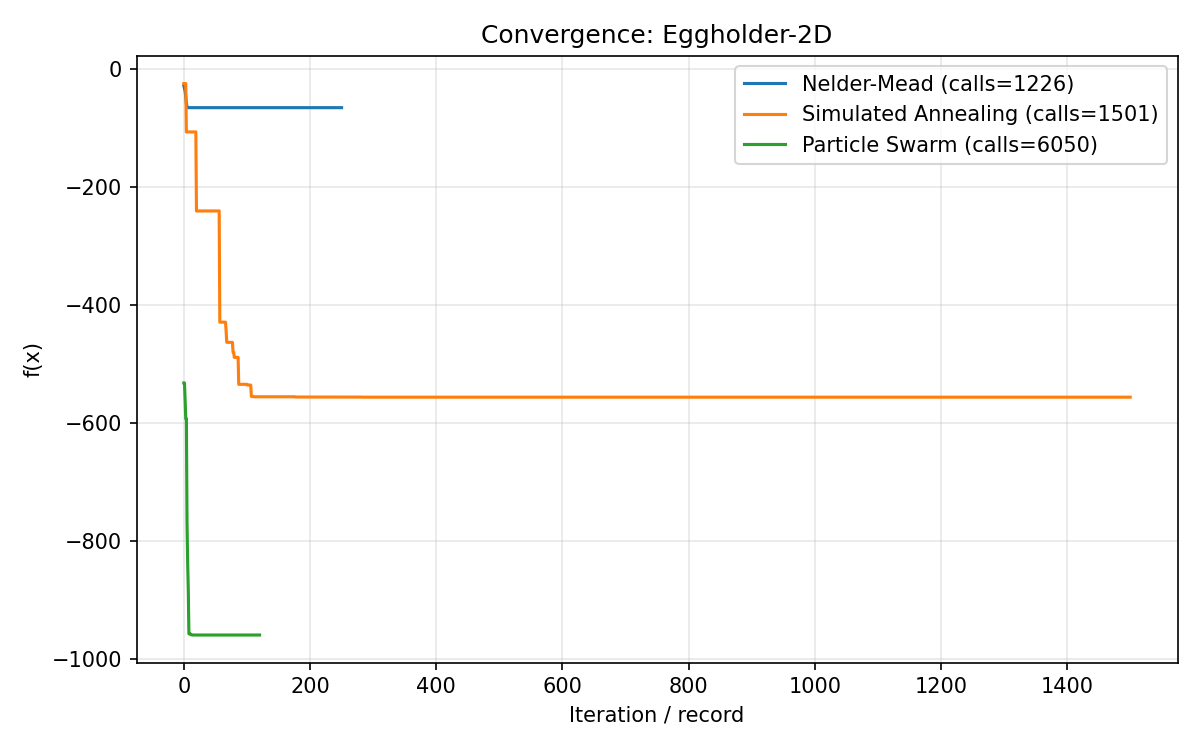

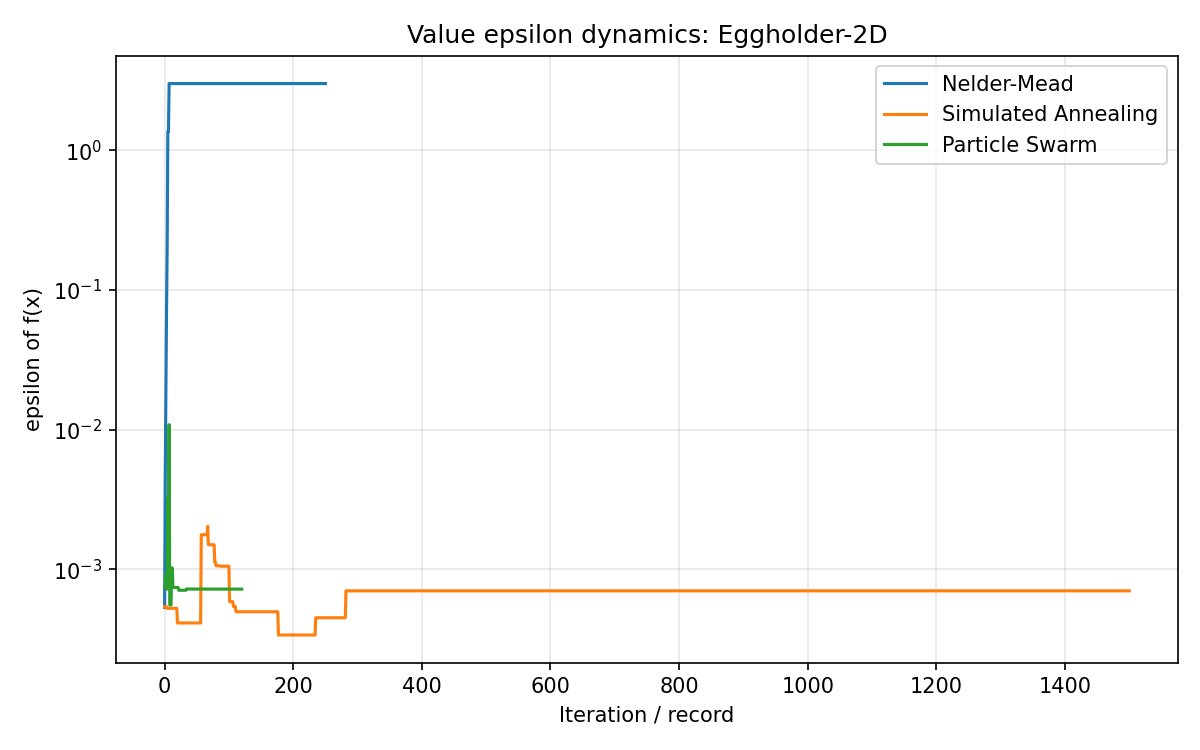

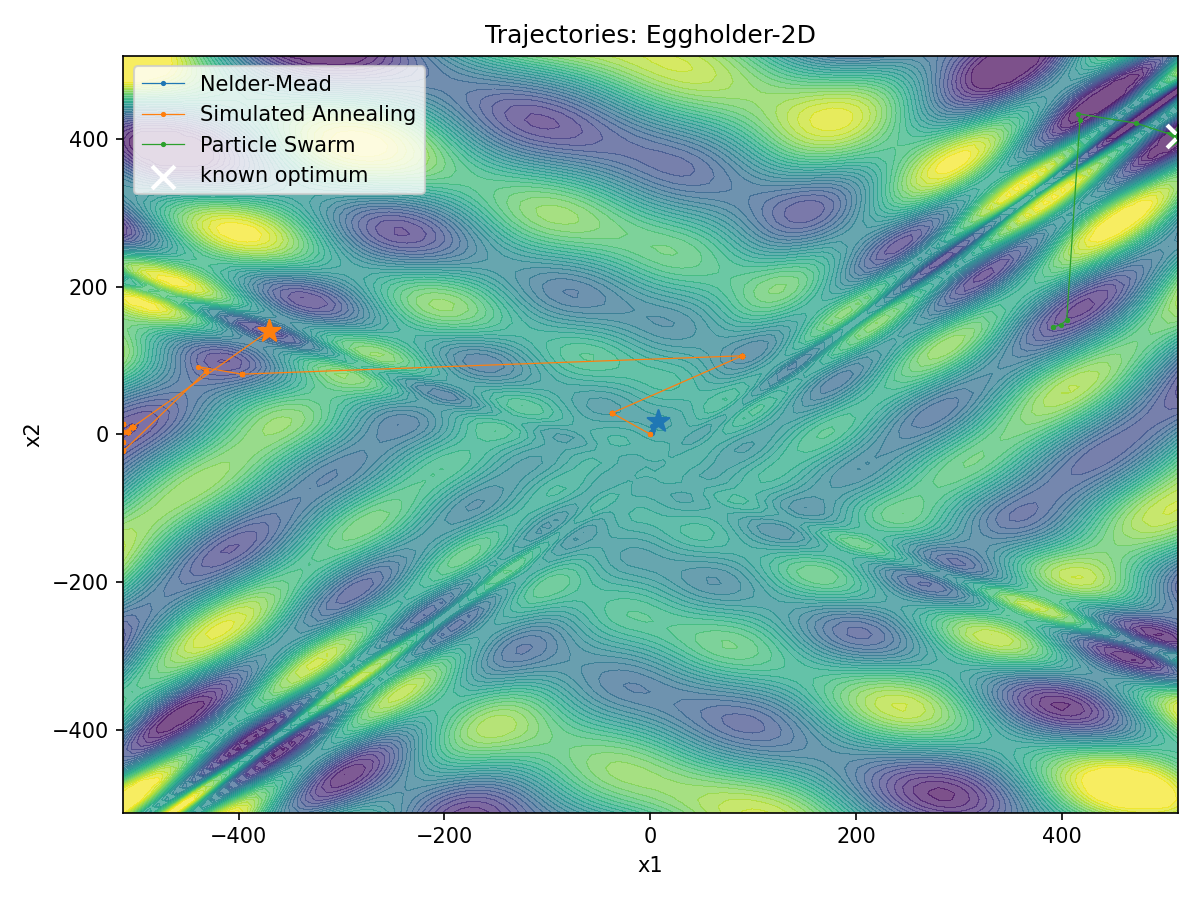

### Badie-2D

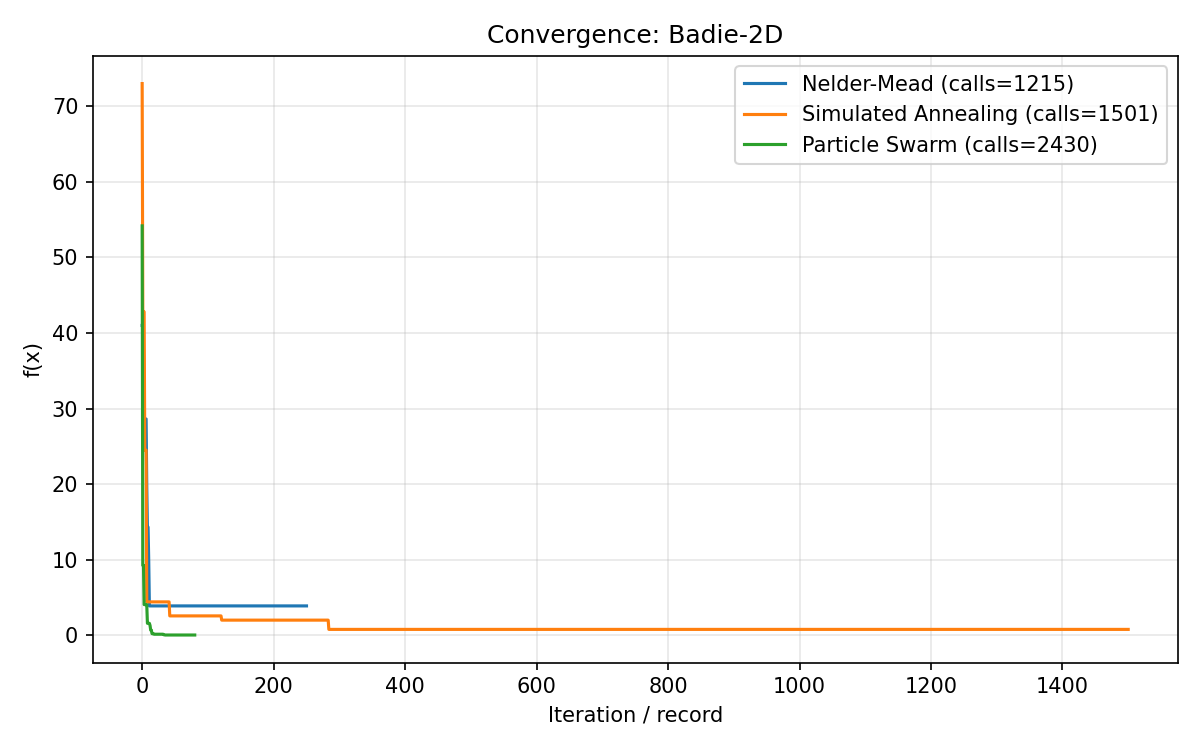

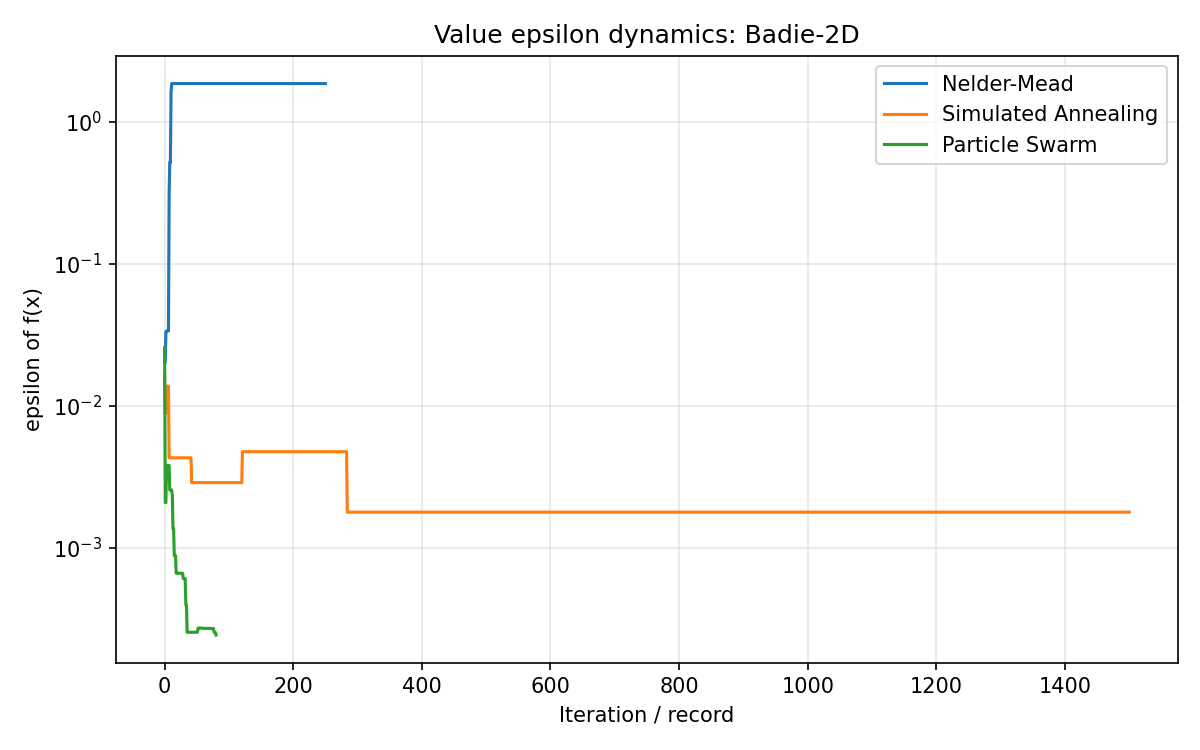

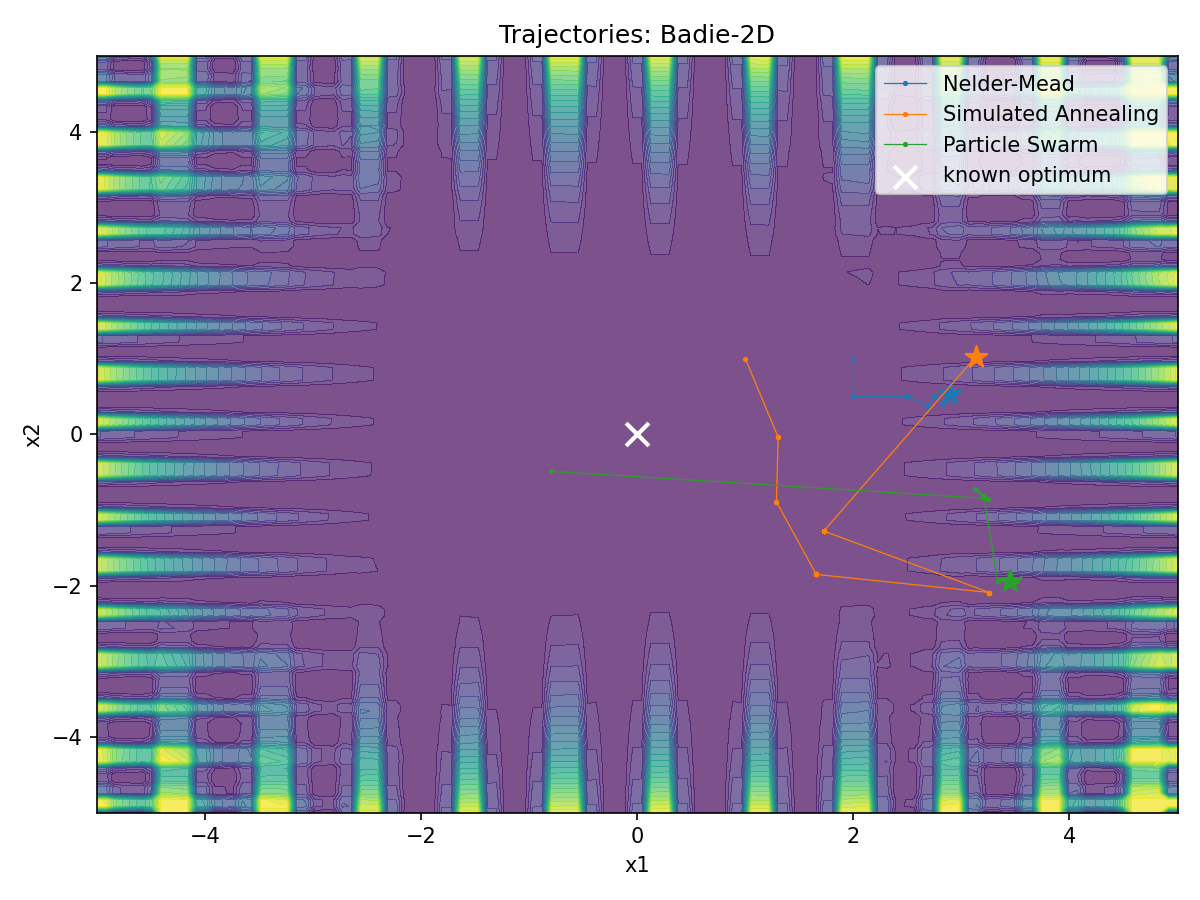

In [4]:
import json
with open(PROJECT_ROOT / 'results' / 'plots.json', encoding='utf-8') as f:
    plots = json.load(f)

from IPython.display import Image, display, Markdown
for func, files in plots.items():
    display(Markdown(f'### {func}'))
    for kind, fname in files.items():
        display(Image(filename=str(PROJECT_ROOT / 'results' / fname)))

## Память: сравнение методов

Memory_scalars — оценка количества скаляров, удерживаемых методом одновременно.

In [5]:
mem = summary.pivot_table(index='function', columns='method', values='memory_scalars', aggfunc='first')
mem

method,Gradient descent,Nelder-Mead,Newton,Particle Swarm,Simulated Annealing
function,,,,,
Ackley-2D,NaN,6.0,NaN,182.0,4.0
Badie-2D,NaN,6.0,NaN,182.0,4.0
Eggholder-2D,NaN,6.0,NaN,302.0,4.0
Himmelblau-2D,NaN,6.0,NaN,182.0,4.0
Quadratic-4D-bad,8.0,20.0,24.0,484.0,8.0
Quadratic-6D-good,12.0,42.0,48.0,726.0,12.0
Rastrigin-2D,NaN,6.0,NaN,182.0,4.0
Rosenbrock-3D,6.0,12.0,15.0,363.0,6.0


## Финальное значение f и расстояние до оптимума

In [6]:
fv = summary.pivot_table(index='function', columns='method', values='final_value', aggfunc='first')
fv

method,Gradient descent,Nelder-Mead,Newton,Particle Swarm,Simulated Annealing
function,,,,,
Ackley-2D,NaN,0.349383,NaN,0.000000e+00,0.297864
Badie-2D,NaN,3.892821,NaN,4.264566e-02,0.785386
Eggholder-2D,NaN,-66.272283,NaN,-9.596407e+02,-556.727347
Himmelblau-2D,NaN,0.069381,NaN,0.000000e+00,0.032128
Quadratic-4D-bad,9.601030e-04,26.980741,0.0000,5.000000e-07,0.005664
Quadratic-6D-good,1.925927e-10,1.983843,0.0000,0.000000e+00,0.078422
Rastrigin-2D,NaN,0.006413,NaN,0.000000e+00,0.381824
Rosenbrock-3D,9.934964e+27,3.797934,0.9112,5.586500e-02,0.042344


In [7]:
dist = summary.pivot_table(index='function', columns='method', values='distance_to_optimum', aggfunc='first')
dist

method,Gradient descent,Nelder-Mead,Newton,Particle Swarm,Simulated Annealing
function,,,,,
Ackley-2D,NaN,0.065592,NaN,0.000120,0.065878
Badie-2D,NaN,2.939037,NaN,3.957782,3.294292
Eggholder-2D,NaN,636.036221,NaN,0.000046,920.634327
Himmelblau-2D,NaN,0.019255,NaN,0.000041,3.938531
Quadratic-4D-bad,4.294663e-02,6.241317,0.00000,0.000391,0.011551
Quadratic-6D-good,1.855126e-09,1.917487,0.00000,0.001536,0.406895
Rastrigin-2D,NaN,0.000000,NaN,0.000055,0.043960
Rosenbrock-3D,1.512202e+04,1.945296,0.29691,0.442228,0.149608


## Выводы

См. подробный анализ в [README.md](./README.md).